# AMR Output Exploration

This notebook reads the prepared-input comparison outputs from `outputs/` and helps inspect:

- per-scope model metrics
- side-by-side scope comparison by antibiotic
- zero-feature and skip-rate diagnostics
- the best-performing scope for each antibiotic
- per-scope feature-importance scores


In [107]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)


In [108]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
RULE_OUTPUT_ROOT = PROJECT_ROOT / 'outputs_rule'
FIGURE_OUTPUT_DIR = PROJECT_ROOT / 'report' / 'figures'
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STRICT_METRICS_PATH = OUTPUT_ROOT / 'strict' / 'metrics.csv'
BROAD_METRICS_PATH = OUTPUT_ROOT / 'broad' / 'metrics.csv'
ALL_METRICS_PATH = OUTPUT_ROOT / 'all' / 'metrics.csv'
RULE_STRICT_METRICS_PATH = RULE_OUTPUT_ROOT / 'strict' / 'metrics.csv'
RULE_BROAD_METRICS_PATH = RULE_OUTPUT_ROOT / 'broad' / 'metrics.csv'
STRICT_SUMMARY_PATH = OUTPUT_ROOT / 'strict' / 'dataset_summary.json'
BROAD_SUMMARY_PATH = OUTPUT_ROOT / 'broad' / 'dataset_summary.json'
ALL_SUMMARY_PATH = OUTPUT_ROOT / 'all' / 'dataset_summary.json'
STRICT_TOP_FEATURES_PATH = OUTPUT_ROOT / 'strict' / 'top_features.csv'
BROAD_TOP_FEATURES_PATH = OUTPUT_ROOT / 'broad' / 'top_features.csv'
ALL_TOP_FEATURES_PATH = OUTPUT_ROOT / 'all' / 'top_features.csv'

for path in [
    STRICT_METRICS_PATH,
    BROAD_METRICS_PATH,
    ALL_METRICS_PATH,
    RULE_STRICT_METRICS_PATH,
    RULE_BROAD_METRICS_PATH,
    STRICT_SUMMARY_PATH,
    BROAD_SUMMARY_PATH,
    ALL_SUMMARY_PATH,
    STRICT_TOP_FEATURES_PATH,
    BROAD_TOP_FEATURES_PATH,
    ALL_TOP_FEATURES_PATH,
]:
    print(path, 'exists=' + str(path.exists()))


d:\Projects\amr-prediction\outputs\strict\metrics.csv exists=True
d:\Projects\amr-prediction\outputs\broad\metrics.csv exists=True
d:\Projects\amr-prediction\outputs\all\metrics.csv exists=True
d:\Projects\amr-prediction\outputs\strict\dataset_summary.json exists=True
d:\Projects\amr-prediction\outputs\broad\dataset_summary.json exists=True
d:\Projects\amr-prediction\outputs\all\dataset_summary.json exists=True
d:\Projects\amr-prediction\outputs\strict\top_features.csv exists=True
d:\Projects\amr-prediction\outputs\broad\top_features.csv exists=True
d:\Projects\amr-prediction\outputs\all\top_features.csv exists=True


In [109]:
strict_metrics = pd.read_csv(STRICT_METRICS_PATH)
broad_metrics = pd.read_csv(BROAD_METRICS_PATH)
all_metrics = pd.read_csv(ALL_METRICS_PATH)
scope_metrics = pd.concat([strict_metrics, broad_metrics, all_metrics], ignore_index=True)

strict_top_features = pd.read_csv(STRICT_TOP_FEATURES_PATH)
broad_top_features = pd.read_csv(BROAD_TOP_FEATURES_PATH)
all_top_features = pd.read_csv(ALL_TOP_FEATURES_PATH)
scope_top_features = pd.concat([strict_top_features, broad_top_features, all_top_features], ignore_index=True)

strict_summary = json.loads(STRICT_SUMMARY_PATH.read_text(encoding='utf-8'))
broad_summary = json.loads(BROAD_SUMMARY_PATH.read_text(encoding='utf-8'))
all_summary = json.loads(ALL_SUMMARY_PATH.read_text(encoding='utf-8'))

scope_order = ['strict', 'broad', 'all']
scope_metrics['scope'] = pd.Categorical(scope_metrics['scope'], categories=scope_order, ordered=True)
scope_metrics = scope_metrics.sort_values(['scope', 'roc_auc', 'Antibiotic'], ascending=[True, False, True]).reset_index(drop=True)
scope_top_features['scope'] = pd.Categorical(scope_top_features['scope'], categories=scope_order, ordered=True)
scope_top_features = scope_top_features.sort_values(['scope', 'Antibiotic', 'rank']).reset_index(drop=True)

display(scope_metrics)


,scope,Antibiotic,n_samples,n_susceptible,n_resistant,n_positive,n_negative,positive_label,positive_fraction,feature_count,zero_feature_rows,roc_auc,average_precision,accuracy,precision,recall,mean_fold_roc_auc,status
0,strict,ciprofloxacin,6550,5951,599,599,5951,resistant,0.091450,39,5932,0.997118,0.992514,0.997405,0.980198,0.991653,0.998196,trained
1,strict,chloramphenicol,6730,6146,584,584,6146,resistant,0.086776,33,6147,0.992728,0.983969,0.998068,0.993092,0.984589,0.993834,trained
2,strict,trimethoprim-sulfamethoxazole,6808,6494,314,314,6494,resistant,0.046122,45,3952,0.991754,0.957301,0.997062,0.968153,0.968153,0.993066,trained
3,strict,tetracycline,6780,1941,4839,4839,1941,resistant,0.713717,21,1924,0.987478,0.991700,0.990413,0.993386,0.993180,0.988803,trained
4,strict,nalidixic acid,6789,5974,815,815,5974,resistant,0.120047,60,5943,0.987353,0.981123,0.993519,0.966143,0.980368,0.990595,trained
5,strict,sulfisoxazole,6558,3845,2713,2713,3845,resistant,0.413693,9,3844,0.984733,0.974050,0.987649,0.985609,0.984519,0.986489,trained
6,strict,gentamicin,6459,5575,884,884,5575,resistant,0.136863,48,5480,0.977994,0.935412,0.980338,0.898002,0.966063,0.980341,trained
7,strict,streptomycin,6050,2850,3200,3200,2850,resistant,0.528926,45,2516,0.958421,0.949752,0.941983,0.921824,0.972812,0.960563,trained
8,strict,kanamycin,2772,2304,468,468,2304,resistant,0.168831,9,2341,0.943017,0.912103,0.978716,0.976690,0.895299,0.947402,trained
9,strict,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,36,5457,0.761499,0.741790,0.830543,0.978423,0.538934,0.766853,trained


In [110]:
scope_run_summary = pd.DataFrame(
    [
        {'scope': strict_summary['scope'], 'prepared_input_dir': strict_summary['prepared_input_dir'], 'n_antibiotics': len(strict_summary['prepared_input_summary'])},
        {'scope': broad_summary['scope'], 'prepared_input_dir': broad_summary['prepared_input_dir'], 'n_antibiotics': len(broad_summary['prepared_input_summary'])},
        {'scope': all_summary['scope'], 'prepared_input_dir': all_summary['prepared_input_dir'], 'n_antibiotics': len(all_summary['prepared_input_summary'])},
    ]
)
display(scope_run_summary)

scope_input_summary = pd.concat(
    [
        pd.DataFrame(strict_summary['prepared_input_summary']).assign(scope='strict'),
        pd.DataFrame(broad_summary['prepared_input_summary']).assign(scope='broad'),
        pd.DataFrame(all_summary['prepared_input_summary']).assign(scope='all'),
    ],
    ignore_index=True,
)
display(scope_input_summary.sort_values(['scope', 'n_samples', 'Antibiotic'], ascending=[True, False, True]))


,scope,prepared_input_dir,n_antibiotics
0,strict,data\model_inputs\strict,14
1,broad,data\model_inputs\broad,14
2,all,data\model_inputs\all,14


,Antibiotic,table_path,n_samples,n_susceptible,n_resistant,feature_count,zero_feature_rows,scope
28,ampicillin,data\model_inputs\all\model_input__ampicillin.csv,6810,4370,2440,417,0,all
29,trimethoprim-sulfamethoxazole,data\model_inputs\all\model_input__trimethoprim_sulfamethoxazole.csv,6808,6494,314,417,0,all
30,ceftriaxone,data\model_inputs\all\model_input__ceftriaxone.csv,6807,5594,1213,414,0,all
31,nalidixic acid,data\model_inputs\all\model_input__nalidixic_acid.csv,6789,5974,815,390,0,all
32,tetracycline,data\model_inputs\all\model_input__tetracycline.csv,6780,1941,4839,408,0,all
33,chloramphenicol,data\model_inputs\all\model_input__chloramphenicol.csv,6730,6146,584,390,0,all
34,cefoxitin,data\model_inputs\all\model_input__cefoxitin.csv,6715,5917,798,408,0,all
35,sulfisoxazole,data\model_inputs\all\model_input__sulfisoxazole.csv,6558,3845,2713,393,0,all
36,ciprofloxacin,data\model_inputs\all\model_input__ciprofloxacin.csv,6550,5951,599,375,0,all
37,gentamicin,data\model_inputs\all\model_input__gentamicin.csv,6459,5575,884,405,0,all


,scope,Antibiotic,status,roc_auc,average_precision,accuracy,precision,recall,feature_count,zero_feature_rows,n_samples,n_susceptible,n_resistant
0,strict,ciprofloxacin,trained,0.997118,0.992514,0.997405,0.980198,0.991653,39,5932,6550,5951,599
1,strict,chloramphenicol,trained,0.992728,0.983969,0.998068,0.993092,0.984589,33,6147,6730,6146,584
2,strict,trimethoprim-sulfamethoxazole,trained,0.991754,0.957301,0.997062,0.968153,0.968153,45,3952,6808,6494,314
3,strict,tetracycline,trained,0.987478,0.991700,0.990413,0.993386,0.993180,21,1924,6780,1941,4839
4,strict,nalidixic acid,trained,0.987353,0.981123,0.993519,0.966143,0.980368,60,5943,6789,5974,815
5,strict,sulfisoxazole,trained,0.984733,0.974050,0.987649,0.985609,0.984519,9,3844,6558,3845,2713
6,strict,gentamicin,trained,0.977994,0.935412,0.980338,0.898002,0.966063,48,5480,6459,5575,884
7,strict,streptomycin,trained,0.958421,0.949752,0.941983,0.921824,0.972812,45,2516,6050,2850,3200
8,strict,kanamycin,trained,0.943017,0.912103,0.978716,0.976690,0.895299,9,2341,2772,2304,468
9,strict,ampicillin,trained,0.761499,0.741790,0.830543,0.978423,0.538934,36,5457,6810,4370,2440


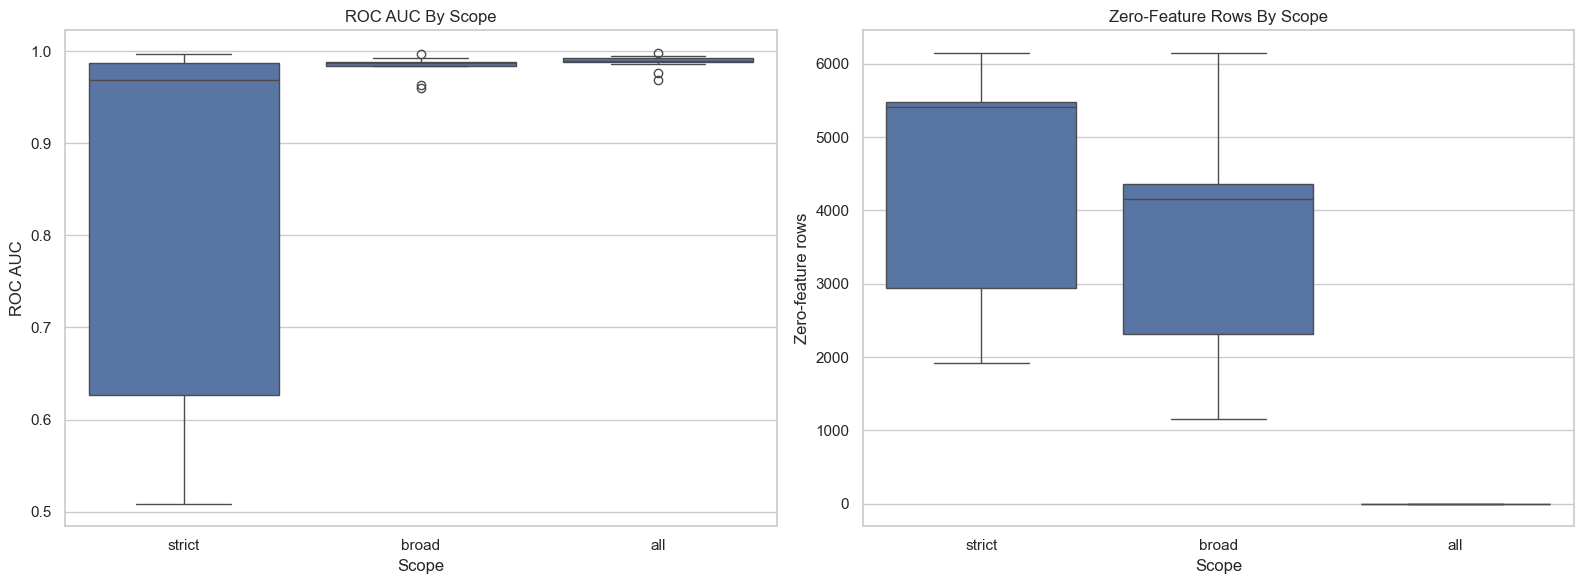

In [111]:
comparison_cols = [
    'scope', 'Antibiotic', 'status', 'roc_auc', 'average_precision', 'accuracy', 'precision', 'recall',
    'feature_count', 'zero_feature_rows', 'n_samples', 'n_susceptible', 'n_resistant'
]
display(scope_metrics[comparison_cols])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=scope_metrics, x='scope', y='roc_auc', order=scope_order, ax=axes[0])
axes[0].set_title('ROC AUC By Scope')
axes[0].set_xlabel('Scope')
axes[0].set_ylabel('ROC AUC')

sns.boxplot(data=scope_metrics, x='scope', y='zero_feature_rows', order=scope_order, ax=axes[1])
axes[1].set_title('Zero-Feature Rows By Scope')
axes[1].set_xlabel('Scope')
axes[1].set_ylabel('Zero-feature rows')

plt.tight_layout()
plt.show()


In [112]:
status_summary = (
    scope_metrics.groupby(['scope', 'status'], observed=True)
    .size()
    .reset_index(name='n_antibiotics')
    .sort_values(['scope', 'status'])
    .reset_index(drop=True)
)
display(status_summary)

skip_rows = scope_metrics[scope_metrics['status'] != 'trained'].copy()
if not skip_rows.empty:
    display(skip_rows.sort_values(['scope', 'Antibiotic']))


,scope,status,n_antibiotics
0,strict,trained,14
1,broad,trained,14
2,all,trained,14


In [113]:
per_antibiotic = scope_metrics.pivot_table(
    index='Antibiotic',
    columns='scope',
    values=['roc_auc', 'average_precision', 'accuracy', 'feature_count', 'zero_feature_rows', 'status'],
    aggfunc='first',
)
per_antibiotic.columns = [f'{metric}_{scope}' for metric, scope in per_antibiotic.columns]
per_antibiotic = per_antibiotic.reset_index()
display(per_antibiotic.sort_values('Antibiotic'))


,Antibiotic,accuracy_strict,accuracy_broad,accuracy_all,average_precision_strict,average_precision_broad,average_precision_all,feature_count_strict,feature_count_broad,feature_count_all,roc_auc_strict,roc_auc_broad,roc_auc_all,status_strict,status_broad,status_all,zero_feature_rows_strict,zero_feature_rows_broad,zero_feature_rows_all
0,amoxicillin-clavulanic acid,0.784218,0.990258,0.990583,0.163598,0.968908,0.976611,24,57,384,0.508625,0.985428,0.988005,trained,trained,trained,5439,4351,0
1,ampicillin,0.830543,0.986344,0.986490,0.741790,0.980212,0.985204,36,75,417,0.761499,0.983947,0.988885,trained,trained,trained,5457,4367,0
2,cefoxitin,0.286969,0.995235,0.994043,0.139649,0.964171,0.972705,33,75,408,0.550073,0.986001,0.989140,trained,trained,trained,5382,4352,0
3,ceftiofur,0.405109,0.993262,0.992981,0.239388,0.977559,0.979043,21,39,288,0.582066,0.988018,0.988685,trained,trained,trained,2640,2028,0
4,ceftriaxone,0.339797,0.994271,0.993536,0.204745,0.978486,0.978490,33,75,414,0.561497,0.988770,0.988884,trained,trained,trained,5458,4365,0
5,chloramphenicol,0.998068,0.998068,0.996285,0.983969,0.983969,0.983717,33,33,390,0.992728,0.992728,0.994830,trained,trained,trained,6147,6147,0
6,ciprofloxacin,0.997405,0.997405,0.997405,0.992514,0.992514,0.994248,39,39,375,0.997118,0.997118,0.998095,trained,trained,trained,5932,5932,0
7,gentamicin,0.980338,0.978944,0.978634,0.935412,0.954173,0.956011,48,111,405,0.977994,0.983462,0.985554,trained,trained,trained,5480,2427,0
8,kanamycin,0.978716,0.984848,0.981241,0.912103,0.942995,0.947375,9,60,210,0.943017,0.962769,0.976001,trained,trained,trained,2341,1159,0
9,nalidixic acid,0.993519,0.993519,0.995286,0.981123,0.981123,0.985481,60,60,390,0.987353,0.987353,0.991995,trained,trained,trained,5943,5943,0


In [114]:
trained_only = scope_metrics[scope_metrics['status'] == 'trained'].copy()
best_scope = (
    trained_only.sort_values(['Antibiotic', 'roc_auc', 'average_precision', 'accuracy'], ascending=[True, False, False, False])
    .drop_duplicates(subset=['Antibiotic'], keep='first')
    [['Antibiotic', 'scope', 'roc_auc', 'average_precision', 'accuracy', 'feature_count', 'zero_feature_rows']]
    .rename(columns={'scope': 'best_scope', 'roc_auc': 'best_roc_auc', 'average_precision': 'best_average_precision', 'accuracy': 'best_accuracy'})
)
display(best_scope.sort_values(['best_roc_auc', 'Antibiotic'], ascending=[False, True]).reset_index(drop=True))


,Antibiotic,best_scope,best_roc_auc,best_average_precision,best_accuracy,feature_count,zero_feature_rows
0,ciprofloxacin,all,0.998095,0.994248,0.997405,375,0
1,chloramphenicol,all,0.994830,0.983717,0.996285,390,0
2,trimethoprim-sulfamethoxazole,all,0.993472,0.971361,0.995153,417,0
3,tetracycline,all,0.992181,0.996110,0.990708,408,0
4,nalidixic acid,all,0.991995,0.985481,0.995286,390,0
5,sulfisoxazole,all,0.991942,0.989936,0.987344,393,0
6,cefoxitin,all,0.989140,0.972705,0.994043,408,0
7,ampicillin,all,0.988885,0.985204,0.986490,417,0
8,ceftriaxone,all,0.988884,0.978490,0.993536,414,0
9,ceftiofur,all,0.988685,0.979043,0.992981,288,0


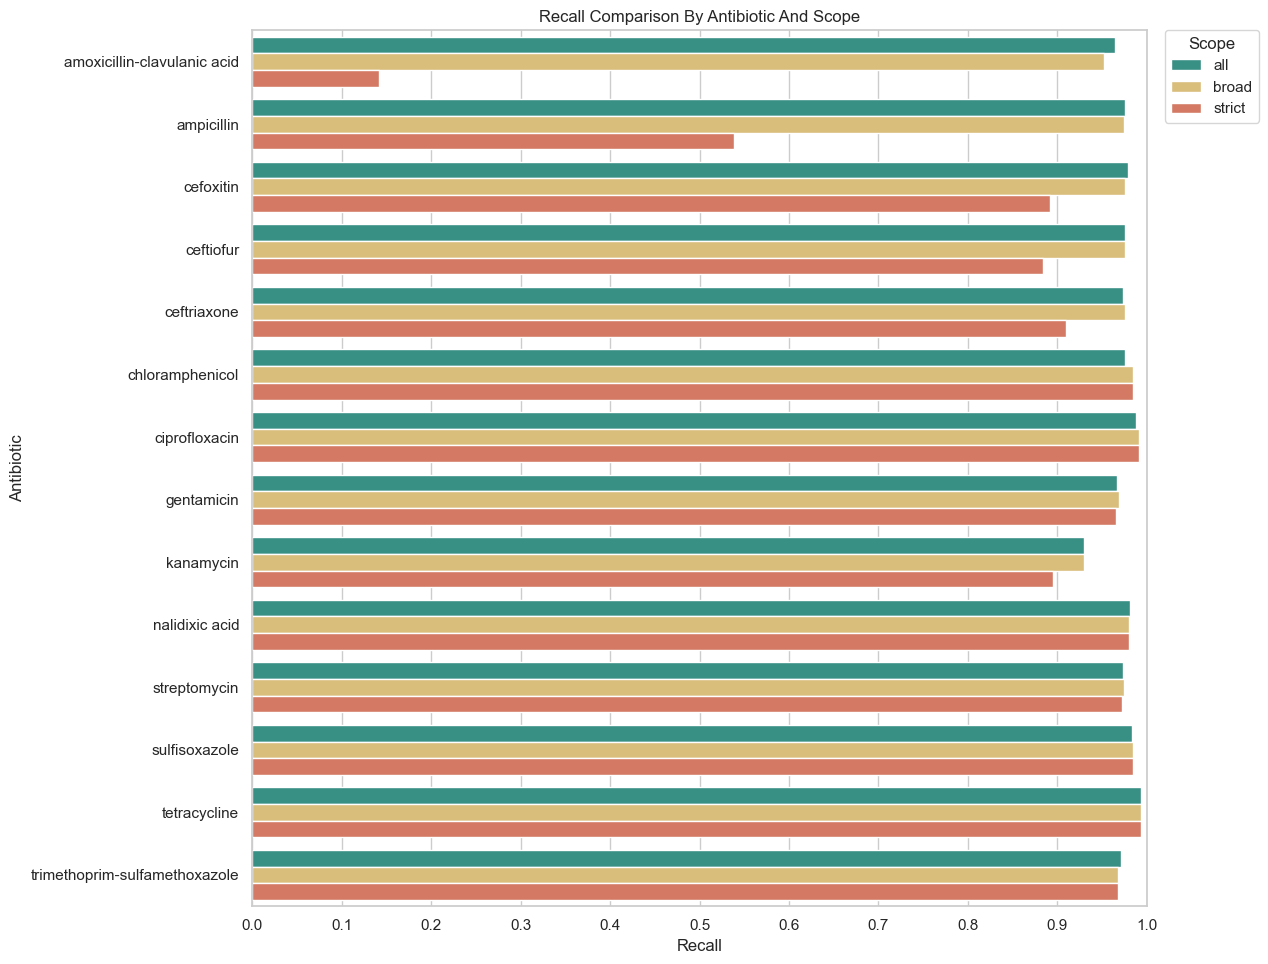

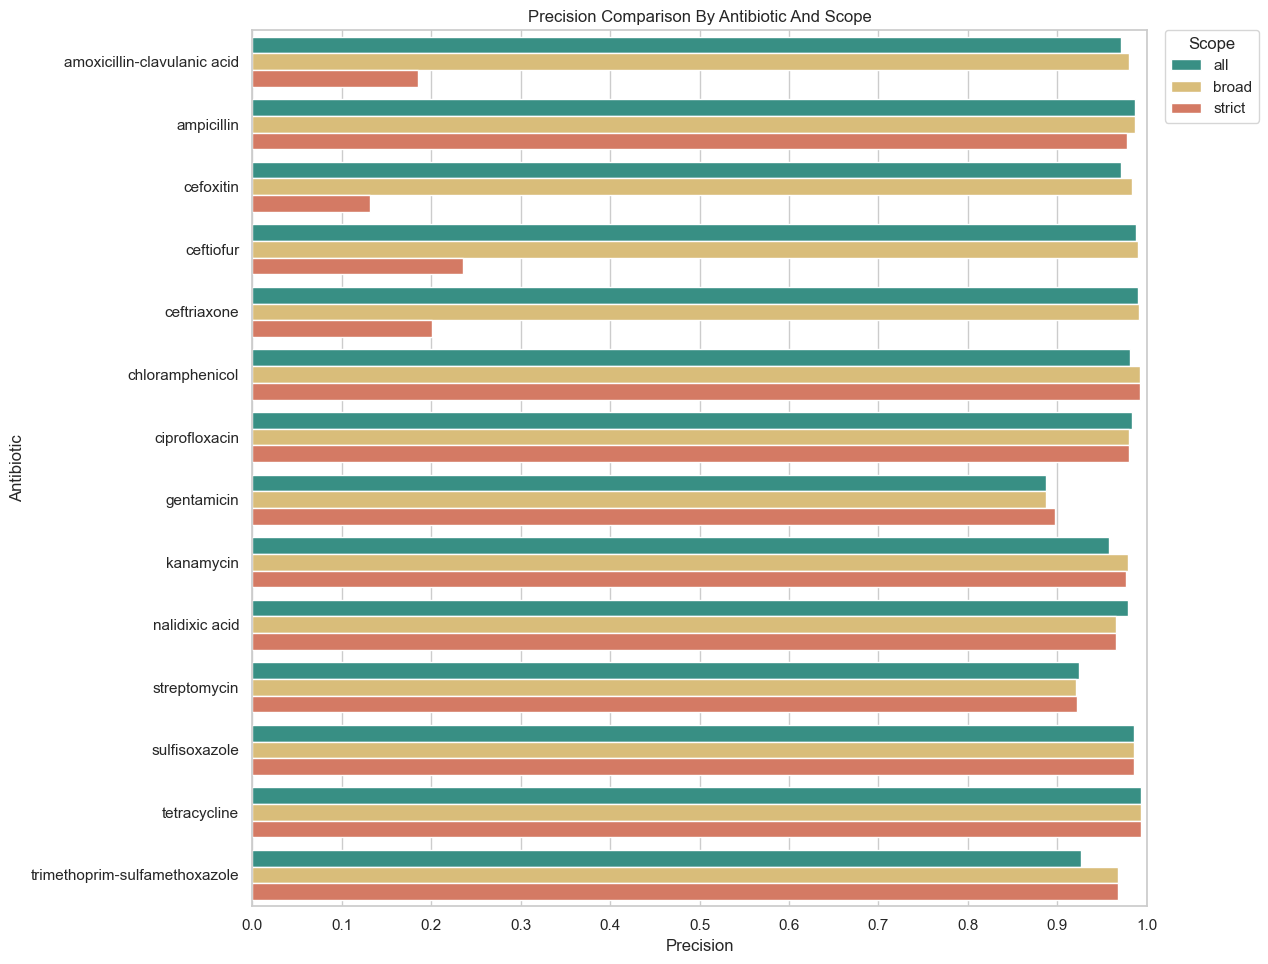

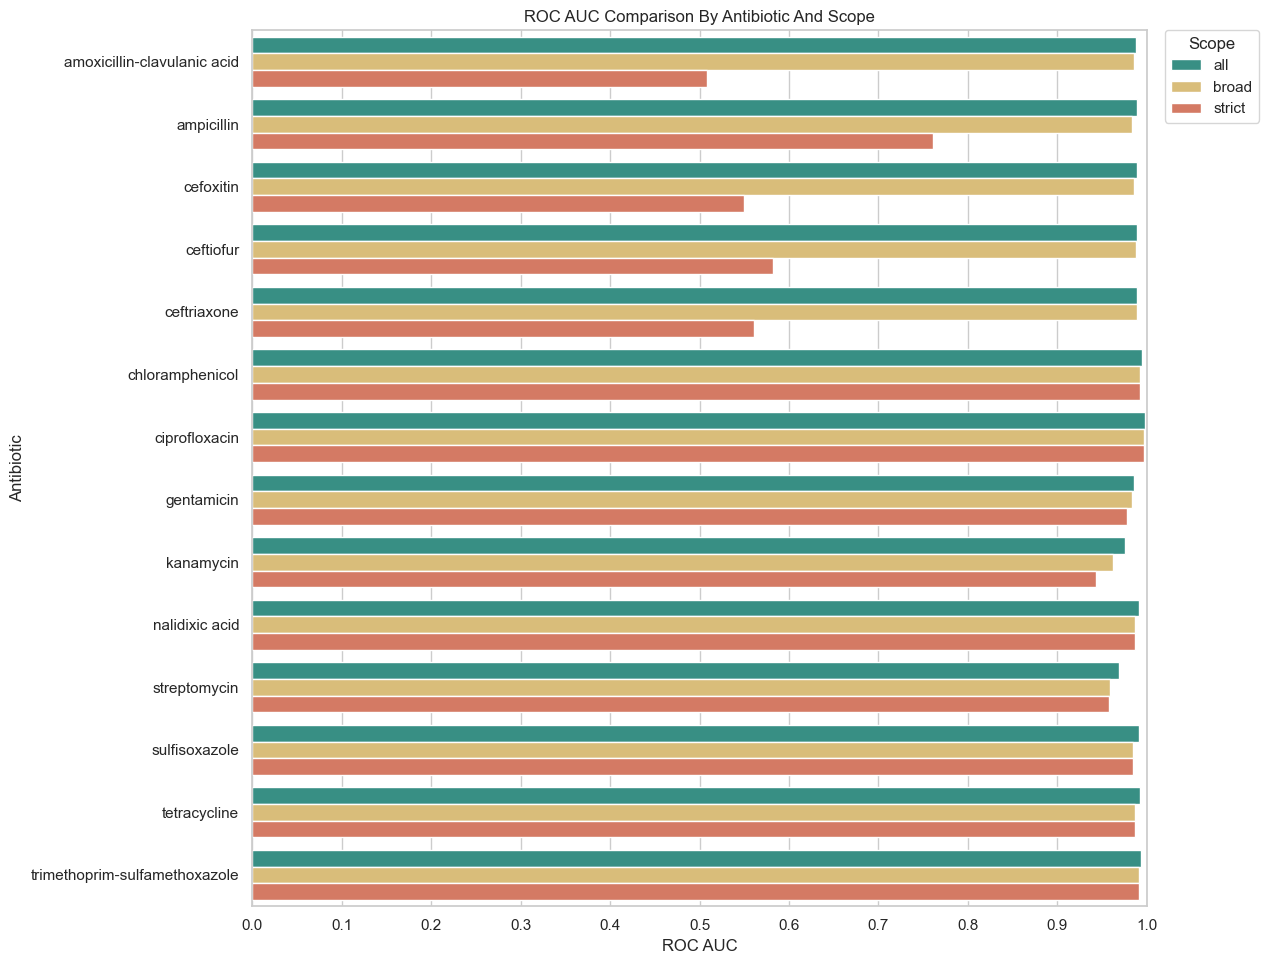

In [115]:
scope_display_order = ['all', 'broad', 'strict']
scope_palette = {'all': '#2a9d8f', 'broad': '#e9c46a', 'strict': '#e76f51'}
metric_specs = [
    ('recall', 'Recall Comparison By Antibiotic And Scope', 'Recall'),
    ('precision', 'Precision Comparison By Antibiotic And Scope', 'Precision'),
    ('roc_auc', 'ROC AUC Comparison By Antibiotic And Scope', 'ROC AUC'),
]

plot_height = max(8, 0.7 * trained_only['Antibiotic'].nunique())
x_ticks = [value / 10 for value in range(0, 11)]

for metric_name, title, xlabel in metric_specs:
    plot_df = trained_only[['Antibiotic', 'scope', metric_name]].copy()
    plot_df['scope'] = pd.Categorical(plot_df['scope'], categories=scope_display_order, ordered=True)
    plot_df = plot_df.sort_values(['Antibiotic', 'scope']).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, plot_height))
    sns.barplot(
        data=plot_df,
        x=metric_name,
        y='Antibiotic',
        hue='scope',
        hue_order=scope_display_order,
        palette=scope_palette,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Antibiotic')
    ax.set_xlim(0, 1)
    ax.set_xticks(x_ticks)
    ax.legend(title='Scope', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=(0, 0, 0.86, 1))
    fig.savefig(FIGURE_OUTPUT_DIR / f'{metric_name}_by_scope.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
rule_strict_metrics = pd.read_csv(RULE_STRICT_METRICS_PATH)
rule_broad_metrics = pd.read_csv(RULE_BROAD_METRICS_PATH)
rule_metrics = pd.concat([rule_strict_metrics, rule_broad_metrics], ignore_index=True)

rule_display_order = ['broad', 'strict']
rule_label_map = {'broad': 'broad rule', 'strict': 'strict rule'}
rule_palette = {'broad rule': '#e9c46a', 'strict rule': '#e76f51'}
rule_metric_specs = [
    ('recall', 'Rule-Based Recall Comparison By Antibiotic And Scope', 'Recall', 'rule_recall_by_scope.png'),
    ('precision', 'Rule-Based Precision Comparison By Antibiotic And Scope', 'Precision', 'rule_precision_by_scope.png'),
]

rule_plot_height = max(8, 0.7 * rule_metrics['Antibiotic'].nunique())
x_ticks = [value / 10 for value in range(0, 11)]

for metric_name, title, xlabel, filename in rule_metric_specs:
    plot_df = rule_metrics[['Antibiotic', 'scope', metric_name]].copy()
    plot_df['scope'] = pd.Categorical(plot_df['scope'], categories=rule_display_order, ordered=True)
    plot_df = plot_df.sort_values(['Antibiotic', 'scope']).reset_index(drop=True)
    plot_df['scope_label'] = plot_df['scope'].map(rule_label_map)

    fig, ax = plt.subplots(figsize=(15, rule_plot_height))
    sns.barplot(
        data=plot_df,
        x=metric_name,
        y='Antibiotic',
        hue='scope_label',
        hue_order=['broad rule', 'strict rule'],
        palette=rule_palette,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Antibiotic')
    ax.set_xlim(0, 1)
    ax.set_xticks(x_ticks)
    ax.legend(title='Scope', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=(0, 0, 0.86, 1))
    fig.savefig(FIGURE_OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


In [118]:
scope_display_order = ['all', 'broad', 'strict']
all_rows = scope_metrics.copy()
all_rows['scope'] = pd.Categorical(all_rows['scope'], categories=scope_display_order, ordered=True)
all_rows = all_rows.sort_values(['Antibiotic', 'scope']).reset_index(drop=True)
display(all_rows)

,scope,Antibiotic,n_samples,n_susceptible,n_resistant,n_positive,n_negative,positive_label,positive_fraction,feature_count,zero_feature_rows,roc_auc,average_precision,accuracy,precision,recall,mean_fold_roc_auc,status
0,all,amoxicillin-clavulanic acid,6159,5262,897,897,5262,resistant,0.145641,384,0,0.988005,0.976611,0.990583,0.970819,0.964326,0.988608,trained
1,broad,amoxicillin-clavulanic acid,6159,5262,897,897,5262,resistant,0.145641,57,4351,0.985428,0.968908,0.990258,0.980482,0.952062,0.987590,trained
2,strict,amoxicillin-clavulanic acid,6159,5262,897,897,5262,resistant,0.145641,24,5439,0.508625,0.163598,0.784218,0.185131,0.141583,0.517978,trained
3,all,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,417,0,0.988885,0.985204,0.986490,0.986733,0.975410,0.989461,trained
4,broad,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,75,4367,0.983947,0.980212,0.986344,0.986727,0.975000,0.986305,trained
5,strict,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,36,5457,0.761499,0.741790,0.830543,0.978423,0.538934,0.766853,trained
6,all,cefoxitin,6715,5917,798,798,5917,resistant,0.118838,408,0,0.989140,0.972705,0.994043,0.971393,0.978697,0.990090,trained
7,broad,cefoxitin,6715,5917,798,798,5917,resistant,0.118838,75,4352,0.986001,0.964171,0.995235,0.983586,0.976190,0.988009,trained
8,strict,cefoxitin,6715,5917,798,798,5917,resistant,0.118838,33,5382,0.550073,0.139649,0.286969,0.131511,0.892231,0.555805,trained
9,all,ceftiofur,3562,2854,708,708,2854,resistant,0.198765,288,0,0.988685,0.979043,0.992981,0.988555,0.975989,0.989066,trained


In [123]:
top_feature_preview = scope_top_features.groupby(['scope', 'Antibiotic'], group_keys=False).head(5).reset_index(drop=True)
display(top_feature_preview)

,scope,Antibiotic,rank,feature,feature_base,feature_type,importance
0,strict,amoxicillin-clavulanic acid,1,blatem_identity,blatem,identity,0.146795
1,strict,amoxicillin-clavulanic acid,2,blatem_1_lineage_match,blatem_1,lineage_match,0.120498
2,strict,amoxicillin-clavulanic acid,3,blatem_coverage,blatem,coverage,0.120052
3,strict,amoxicillin-clavulanic acid,4,blaher_identity,blaher,identity,0.106200
4,strict,amoxicillin-clavulanic acid,5,blatem_lineage_match,blatem,lineage_match,0.096805
...,...,...,...,...,...,...,...
205,all,trimethoprim-sulfamethoxazole,1,dfra14_lineage_match,dfra14,lineage_match,0.166733
206,all,trimethoprim-sulfamethoxazole,2,dfra14_coverage,dfra14,coverage,0.122734
207,all,trimethoprim-sulfamethoxazole,3,dfra14_identity,dfra14,identity,0.098069
208,all,trimethoprim-sulfamethoxazole,4,aada2_identity,aada2,identity,0.058639


## Feature Table Example

This table shows a small real slice of one prepared model-input file in the same wide format used for training. The rows are only filtered to find examples with some non-100 coverage or identity values.


In [117]:
example_scope = 'all'
example_antibiotic = 'gentamicin'
example_input_path = PROJECT_ROOT / 'data' / 'model_inputs' / example_scope / f'model_input__{example_antibiotic}.csv'
example_df = pd.read_csv(example_input_path)

candidate_feature_bases = [
    'gyra_s83f',
    'fosa7',
    'tet_b',
    'cmla1',
    'sul1',
]

shown_columns = ['BioSample', 'Resistance phenotype', 'y']
for feature_base in candidate_feature_bases:
    shown_columns.extend(
        [
            f'{feature_base}_coverage',
            f'{feature_base}_identity',
            f'{feature_base}_lineage_match',
        ]
    )

diverse_value_mask = pd.Series(False, index=example_df.index)
for feature_base in candidate_feature_bases:
    diverse_value_mask = diverse_value_mask | (
        (
            (example_df[f'{feature_base}_coverage'] != 0)
            | (example_df[f'{feature_base}_identity'] != 0)
        )
        & (
            (example_df[f'{feature_base}_coverage'] != 100)
            | (example_df[f'{feature_base}_identity'] != 100)
        )
    )

feature_table_example = example_df.loc[diverse_value_mask, shown_columns].copy()
feature_table_example = feature_table_example.sort_values(['Resistance phenotype', 'BioSample']).head(6).reset_index(drop=True)
display(feature_table_example)

display(
    pd.DataFrame(
        {
            'scope': [example_scope],
            'antibiotic': [example_antibiotic],
            'input_file': [str(example_input_path)],
            'shown_feature_bases': [', '.join(candidate_feature_bases)],
            'selection_rule': ['wide model-input rows where a shown feature has non-zero values and coverage != 100 or identity != 100'],
        }
    )
)


,BioSample,Resistance phenotype,y,gyra_s83f_coverage,gyra_s83f_identity,gyra_s83f_lineage_match,fosa7_coverage,fosa7_identity,fosa7_lineage_match,tet_b_coverage,tet_b_identity,tet_b_lineage_match,cmla1_coverage,cmla1_identity,cmla1_lineage_match,sul1_coverage,sul1_identity,sul1_lineage_match
0,SAMN02640795,resistant,1,100.0,99.89,0,0.0,0.0,0,0.00,0.0,0,0.0,0.00,0,100.0,100.00,0
1,SAMN02640799,resistant,1,100.0,99.89,0,0.0,0.0,0,100.00,100.0,0,0.0,0.00,0,100.0,100.00,0
2,SAMN02640872,resistant,1,100.0,99.89,0,0.0,0.0,0,0.00,0.0,0,0.0,0.00,0,100.0,100.00,0
3,SAMN02699223,resistant,1,0.0,0.00,0,100.0,100.0,0,100.00,100.0,0,100.0,99.76,0,0.0,0.00,0
4,SAMN02699355,resistant,1,0.0,0.00,0,100.0,100.0,0,96.01,100.0,0,0.0,0.00,0,100.0,100.00,0
5,SAMN03269359,resistant,1,0.0,0.00,0,0.0,0.0,0,0.00,0.0,0,0.0,0.00,0,100.0,99.64,0


,scope,antibiotic,input_file,shown_feature_bases,selection_rule
0,all,gentamicin,d:\Projects\amr-prediction\data\model_inputs\all\model_input__gentamicin.csv,"gyra_s83f, fosa7, tet_b, cmla1, sul1",wide model-input rows where a shown feature has non-zero values and coverage != 100 or identity != 100
